<style>
@media print {
    @page {
        size: landscape;
    }
}
</style>

<div style="text-align: center; border: 2px solid #000; padding: 50px; margin: 20px;">
    <h1 style="font-size: 30px;">Calidad de Software con modelos predictivos</h1>
    <br>
    <h2 style="font-size: 24px;">Proyecto de Clasificación</h2>
    <br><br>
    <p style="font-size: 18px;"><strong>Presenta:</strong></p>
    <p style="font-size: 20px;">Marvin Salvador Bacilio Anota</p>
    <br>
    <p style="font-size: 18px;"><strong>Profesora:</strong></p>
    <p style="font-size: 20px;">Dra. Verónica Rodríguez López</p>
    <br><br>
    <p style="font-size: 16px;">Fecha: 9 de marzo de 2026</p>
</div>

<div style="page-break-after: always;"></div>

El conjunto de datos está compuesto por 622 instancias y no presenta valores faltantes, ya que todas las columnas tienen un conteo completo de observaciones. Esto garantiza que no es necesario aplicar técnicas de imputación y que los análisis posteriores no se ven afectados por datos incompletos.

La mayoría de las variables corresponden a atributos de calidad del software y están codificadas de forma binaria (0/1). Esto se confirma observando que los valores mínimos y máximos son 0 y 1 respectivamente, y que las medias representan proporciones de ocurrencia.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. Cargar datos (Windows)
# -------------------------
ruta = r"C:\Users\Marvi\OneDrive\Documentos\GitHub\Proyecto-Veronica\PROMISE-relabeled-NICE.csv"
df = pd.read_csv(ruta)

In [7]:
display(df.head())
print("Dimensiones:", df.shape)


,ProjectID,RequirementText,IsFunctional,IsQuality,Availability (A),Fault Tolerance (FT),Legal (L),Look & Feel (LF),Maintainability (MN),Operability (O),Performance (PE),Portability (PO),Scalability (SC),Security (SE),Usability (US),Other (OT)
0,1,'The system shall refresh the display every 60...,1,1,0,0,0,0,0,0,1,0,0,0,0,0
1,1,'The application shall match the color of the ...,0,1,0,0,1,1,0,0,0,0,0,0,0,0
2,1,'If projected the data must be readable. On a ...,0,1,0,0,0,1,0,0,0,0,0,0,1,0
3,1,'The product shall be available during normal ...,0,1,1,0,0,0,0,0,0,0,0,0,0,0
4,1,'If projected the data must be understandable....,0,1,0,0,0,1,0,0,0,0,0,0,1,0


Dimensiones: (622, 16)


In [8]:
# 1. Lista de todas las columnas excepto la de texto
columnas_a_convertir = [
    'ProjectID', 'IsFunctional', 'IsQuality', 'Availability (A)', 
    'Fault Tolerance (FT)', 'Legal (L)', 'Look & Feel (LF)', 
    'Maintainability (MN)', 'Operability (O)', 'Performance (PE)', 
    'Portability (PO)', 'Scalability (SC)', 'Security (SE)', 
    'Usability (US)', 'Other (OT)'
]

# 2. Conversión masiva a tipo categórico
for col in columnas_a_convertir:
    df[col] = df[col].astype('category')

# 3. Verificación de los nuevos tipos de datos
print("Tipos de datos actualizados:")
print(df.dtypes)

Tipos de datos actualizados:
ProjectID               category
RequirementText              str
IsFunctional            category
IsQuality               category
Availability (A)        category
Fault Tolerance (FT)    category
Legal (L)               category
Look & Feel (LF)        category
Maintainability (MN)    category
Operability (O)         category
Performance (PE)        category
Portability (PO)        category
Scalability (SC)        category
Security (SE)           category
Usability (US)          category
Other (OT)              category
dtype: object


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ProjectID             622 non-null    category
 1   RequirementText       622 non-null    str     
 2   IsFunctional          622 non-null    category
 3   IsQuality             622 non-null    category
 4   Availability (A)      622 non-null    category
 5   Fault Tolerance (FT)  622 non-null    category
 6   Legal (L)             622 non-null    category
 7   Look & Feel (LF)      622 non-null    category
 8   Maintainability (MN)  622 non-null    category
 9   Operability (O)       622 non-null    category
 10  Performance (PE)      622 non-null    category
 11  Portability (PO)      622 non-null    category
 12  Scalability (SC)      622 non-null    category
 13  Security (SE)         622 non-null    category
 14  Usability (US)        622 non-null    category
 15  Other (OT)       

In [10]:
df.describe()

,ProjectID,RequirementText,IsFunctional,IsQuality,Availability (A),Fault Tolerance (FT),Legal (L),Look & Feel (LF),Maintainability (MN),Operability (O),Performance (PE),Portability (PO),Scalability (SC),Security (SE),Usability (US),Other (OT)
count,622,622,622,622,622,622,622,622,622,622,622,622,622,622,622,622
unique,15,622,2,2,2,2,2,2,2,2,2,2,2,2,2,1
top,8,'The system shall refresh the display every 60...,0,1,0,0,0,0,0,0,0,0,0,0,0,0
freq,92,1,314,381,584,606,591,553,588,564,559,600,593,547,537,622


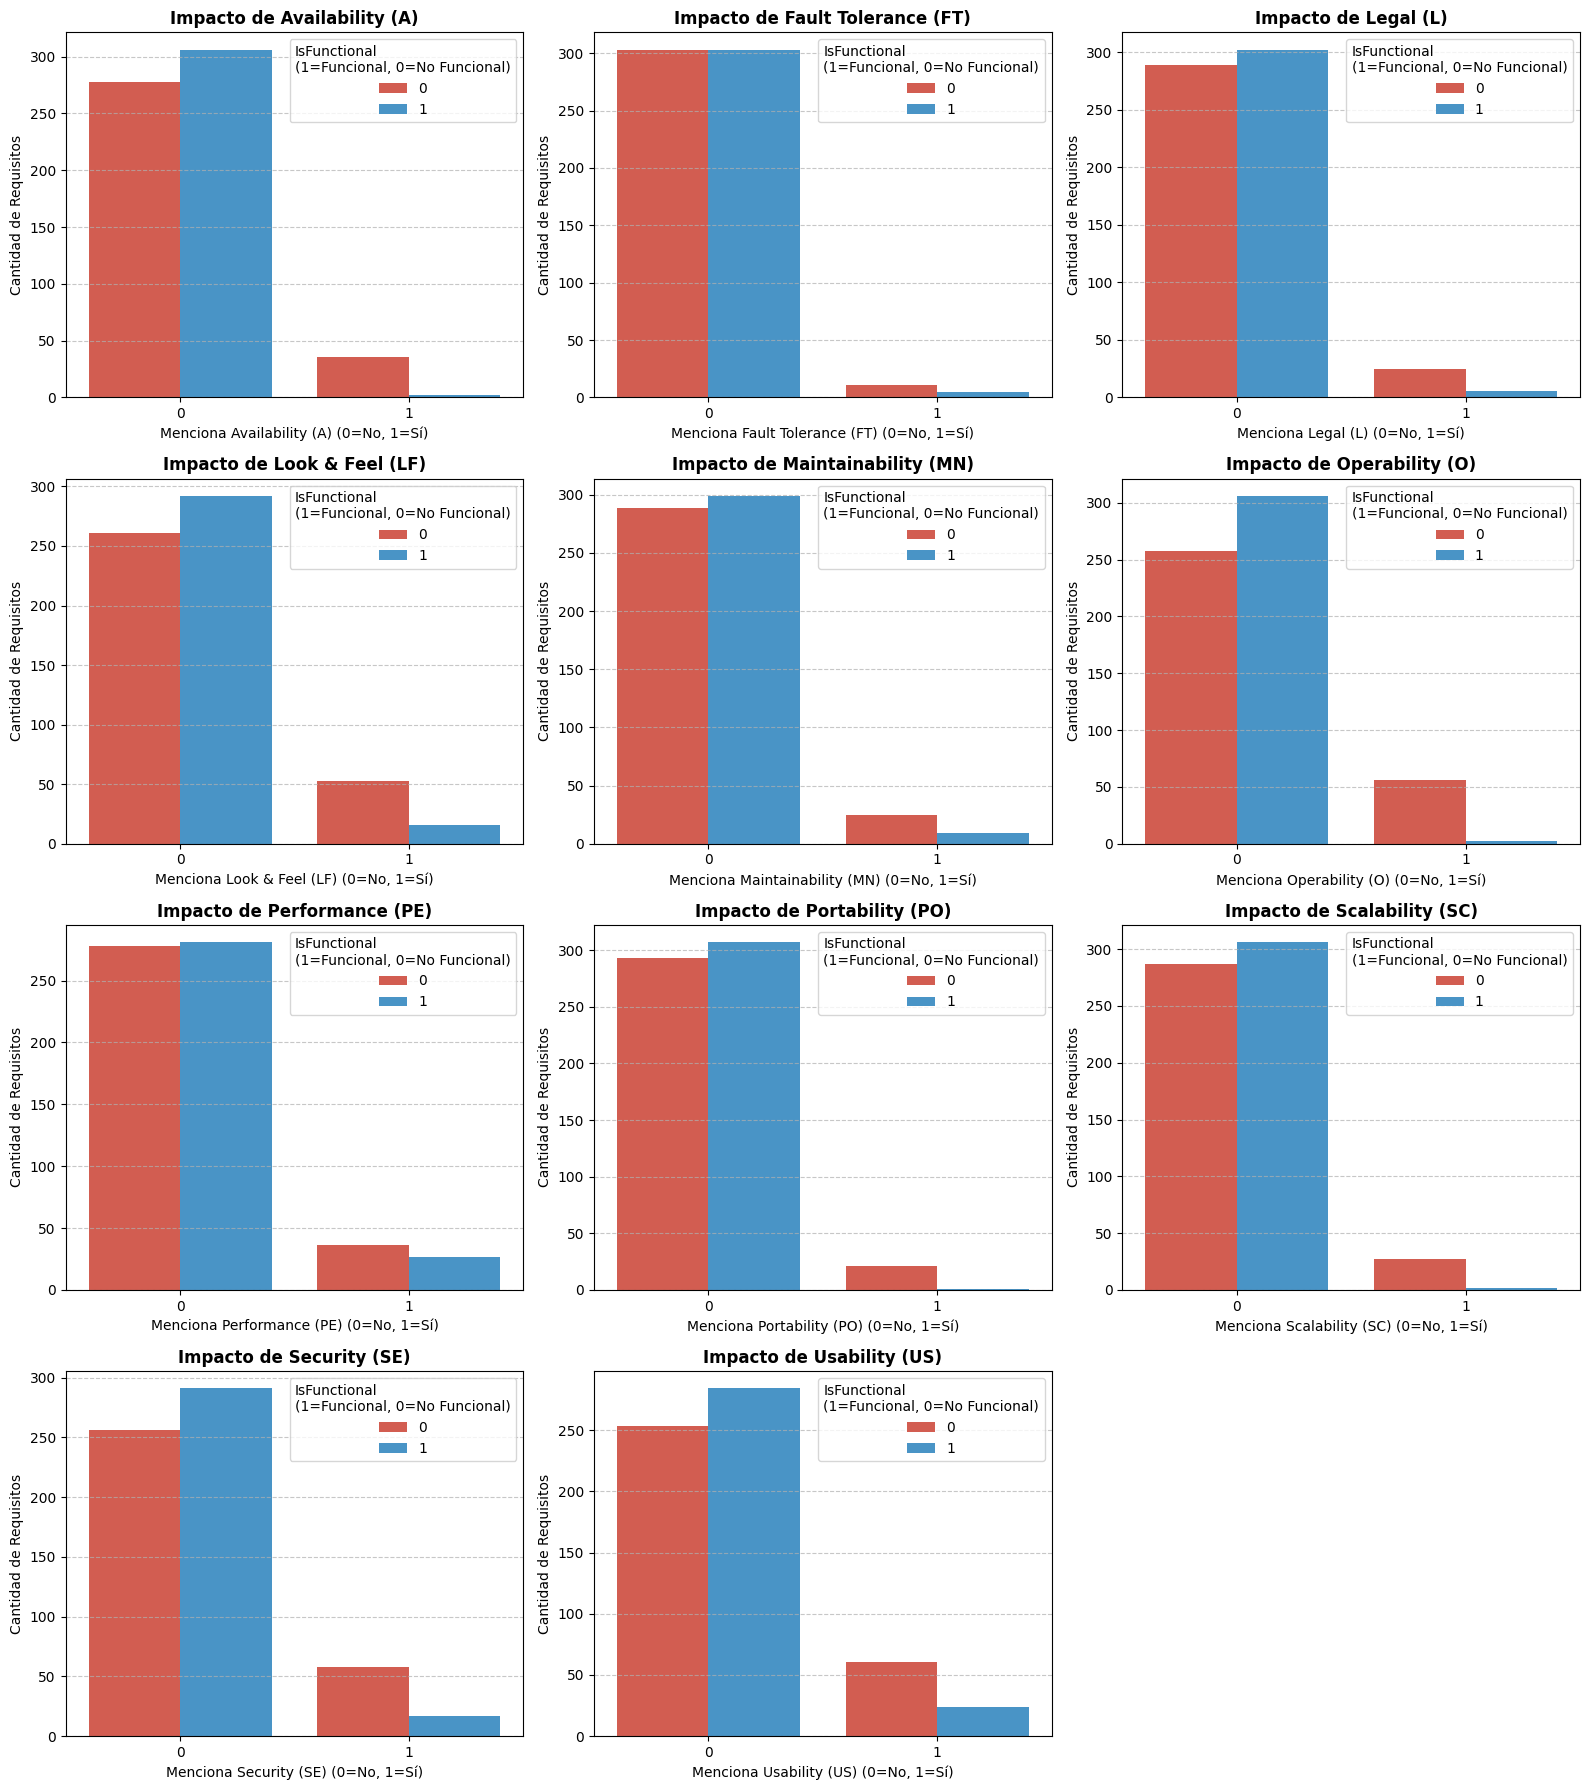

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir las características de interés reales (excluimos 'IsQuality' y 'Other (OT)')
features = [
    'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 
    'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 
    'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 
    'Security (SE)', 'Usability (US)'
]

# 2. Tu verdadera variable objetivo
target = 'IsFunctional'

# 3. Preprocesamiento: Convertir a tipo categórico para el análisis
for col in features + [target]:
    df[col] = df[col].astype('category')

# ==========================================
# 4. CREACIÓN DE LAS GRÁFICAS DE BARRAS (SUBPLOTS)
# ==========================================
# Configurar la cuadrícula: 4 filas x 3 columnas para que quepan las 11 gráficas
num_features = len(features)
cols = 3
rows = (num_features // cols) + (1 if num_features % cols > 0 else 0)

# Crear la figura base grande
fig, axes = plt.subplots(rows, cols, figsize=(16, 18))
axes = axes.flatten() # Aplanar para iterar fácilmente

# Iterar y graficar
for i, feature in enumerate(features):
    sns.countplot(
        data=df, 
        x=feature, 
        hue=target, 
        palette={0: '#e74c3c', 1: '#3498db'}, # Colores para 0 (No funcional) y 1 (Funcional)
        ax=axes[i]
    )
    axes[i].set_title(f'Impacto de {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'Menciona {feature} (0=No, 1=Sí)', fontsize=10)
    axes[i].set_ylabel('Cantidad de Requisitos', fontsize=10)
    axes[i].legend(title='IsFunctional\n(1=Funcional, 0=No Funcional)', loc='upper right')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Ocultar el último recuadro vacío (el número 12, ya que solo hay 11 características)
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

# Ajustar diseño para que no se amontonen los títulos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

#### El análisis descriptivo confirma que las variables del conjunto de datos son mayoritariamente binarias y altamente desbalanceadas. Las medias representan la proporción de ocurrencia de cada atributo de calidad, observándose que algunos atributos son poco frecuentes. Se detectó además una característica con varianza nula (Other), la cual fue excluida de los análisis posteriores.

In [12]:
df.isnull().values.any()


np.False_

In [13]:
nombres_columnas = df.columns.tolist()
print(nombres_columnas)
print(df.dtypes)

['ProjectID', 'RequirementText', 'IsFunctional', 'IsQuality', 'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 'Security (SE)', 'Usability (US)', 'Other (OT)']
ProjectID               category
RequirementText              str
IsFunctional            category
IsQuality               category
Availability (A)        category
Fault Tolerance (FT)    category
Legal (L)               category
Look & Feel (LF)        category
Maintainability (MN)    category
Operability (O)         category
Performance (PE)        category
Portability (PO)        category
Scalability (SC)        category
Security (SE)           category
Usability (US)          category
Other (OT)              category
dtype: object


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Definir nuestras variables X (predictoras) e y (objetivo)
# Excluimos ProjectID (es ruido) e IsQuality (espejo del target)
X_text = df['RequirementText']
X_categorical = df[features] # Tus 11 variables categóricas ya definidas
y = df['IsFunctional']

# 2. División de datos (80% entrenamiento, 20% prueba)
# stratify=y asegura que la proporción de funcionales/no funcionales se mantenga en ambos sets
X_train_text, X_test_text, X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_text, X_categorical, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Vectorización del Texto (TF-IDF)
# Ajustamos SOLO en los datos de entrenamiento para evitar data leakage
tfidf = TfidfVectorizer(stop_words='english', max_features=500) # Puedes ajustar max_features
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

# Convertir el resultado TF-IDF a DataFrame para poder unirlo con las categóricas
df_train_tfidf = pd.DataFrame(X_train_tfidf, columns=tfidf.get_feature_names_out(), index=X_train_cat.index)
df_test_tfidf = pd.DataFrame(X_test_tfidf, columns=tfidf.get_feature_names_out(), index=X_test_cat.index)

# Unir las características de texto (TF-IDF) con las características categóricas (0 y 1)
X_train_final = pd.concat([df_train_tfidf, X_train_cat], axis=1)
X_test_final = pd.concat([df_test_tfidf, X_test_cat], axis=1)

# 4. Balanceo de datos usando SMOTE (Solo en el set de entrenamiento)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print("Preprocesamiento completado.")
print(f"Tamaño del set de entrenamiento balanceado: {X_train_balanced.shape}")
print(f"Tamaño del set de prueba: {X_test_final.shape}")

Preprocesamiento completado.
Tamaño del set de entrenamiento balanceado: (502, 511)
Tamaño del set de prueba: (125, 511)


El análisis de las medias muestra que la mayoría de los atributos de calidad son poco frecuentes, lo que implica distribuciones altamente desbalanceadas. Este comportamiento explica por qué ciertas visualizaciones como los boxplots o las gráficas de densidad no resultan informativas, ya que la mayor parte de los valores se concentran en cero.

Por esta razón, las visualizaciones más adecuadas para este tipo de datos son los gráficos de conteo y las tablas de contingencia, que permiten observar directamente la frecuencia de ocurrencia de cada categoría en relación con la variable objetivo.

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Función para calcular la V de Cramer entre dos variables categóricas
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Ajuste de sesgo para V de Cramer
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 1. Definir características (excluyendo la de varianza nula)
features_to_rank = [f for f in features if f != 'Other (OT)']

# 2. Paso 1 y 2: Relevancia inicial con el Target (IsQuality)
relevance_v = {f: cramers_v(df[f], df[target]) for f in features_to_rank}

# 3. Paso 3: Seleccionar s1 (mayor V de Cramer con el target)
selected = []
s1 = max(relevance_v, key=relevance_v.get)
selected.append(s1)
remaining = [f for f in features_to_rank if f != s1]

# 4. Paso 4 en adelante: Algoritmo de ranking (MRMR con V de Cramer)
alpha = 0.5 # Balance entre Relevancia y Redundancia

while remaining:
    scores = {}
    for f in remaining:
        rel = relevance_v[f]
        # Redundancia: V de Cramer promedio con las ya seleccionadas
        red = np.mean([cramers_v(df[f], df[s]) for s in selected])
        
        # Puntuación combinada
        scores[f] = (1 - alpha) * rel - alpha * red
    
    best_f = max(scores, key=scores.get)
    selected.append(best_f)
    remaining.remove(best_f)

# Mostrar resultados
print("Ranking Final (Basado en V de Cramer):")
for i, f in enumerate(selected, 1):
    print(f"s{i}: {f} (Asociación con target: {relevance_v[f]:.4f})")

Ranking Final (Basado en V de Cramer):
s1: Operability (O) (Asociación con target: 0.2874)
s2: Availability (A) (Asociación con target: 0.2155)
s3: Scalability (SC) (Asociación con target: 0.1765)
s4: Security (SE) (Asociación con target: 0.1899)
s5: Look & Feel (LF) (Asociación con target: 0.1765)
s6: Portability (PO) (Asociación con target: 0.1587)
s7: Legal (L) (Asociación con target: 0.1246)
s8: Usability (US) (Asociación con target: 0.1598)
s9: Maintainability (MN) (Asociación con target: 0.0958)
s10: Fault Tolerance (FT) (Asociación con target: 0.0285)
s11: Performance (PE) (Asociación con target: 0.0000)


In [16]:
import pandas as pd

# Definimos las características categóricas
caracteristicas = [
    'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 
    'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 
    'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 
    'Security (SE)', 'Usability (US)'
]

# Códigos ANSI solo para resaltar lo más importante
BOLD = '\033[1m'
END = '\033[0m'

# Frecuencia de tu variable objetivo (AQUÍ APLICAMOS LA NEGRITA)
print(f"{BOLD}=== FRECUENCIA DE LA VARIABLE OBJETIVO ==={END}")
conteo_target = df['IsFunctional'].value_counts()
porcentaje_target = df['IsFunctional'].value_counts(normalize=True) * 100

tabla_target = pd.DataFrame({
    'Conteo': conteo_target,
    'Porcentaje (%)': porcentaje_target.round(2)
})

print(f"{BOLD}--- IsFunctional ---{END}")
print(f"{BOLD}{tabla_target}{END}")


print("")
print("=== FRECUENCIAS DE LAS CARACTERÍSTICAS ===\n")

for col in caracteristicas:
    # Frecuencia absoluta (conteo)
    conteo = df[col].value_counts()
    
    # Frecuencia relativa (porcentaje)
    porcentaje = df[col].value_counts(normalize=True) * 100
    
    # Tabla estructurada
    tabla = pd.DataFrame({
        'Conteo': conteo,
        'Porcentaje (%)': porcentaje.round(2)
    })
    
    print(f"--- {col} ---")
    print(tabla)
    print("-" * 35 + "\n")



=== FRECUENCIA DE LA VARIABLE OBJETIVO ===
--- IsFunctional ---
              Conteo  Porcentaje (%)
IsFunctional                        
0                314           50.48
1                308           49.52

=== FRECUENCIAS DE LAS CARACTERÍSTICAS ===

--- Availability (A) ---
                  Conteo  Porcentaje (%)
Availability (A)                        
0                    584           93.89
1                     38            6.11
-----------------------------------

--- Fault Tolerance (FT) ---
                      Conteo  Porcentaje (%)
Fault Tolerance (FT)                        
0                        606           97.43
1                         16            2.57
-----------------------------------

--- Legal (L) ---
           Conteo  Porcentaje (%)
Legal (L)                        
0             591           95.02
1              31            4.98
-----------------------------------

--- Look & Feel (LF) ---
                  Conteo  Porcentaje (%)
Look & Feel (L

In [17]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import scipy.stats as stats

# 1. Definir características
caracteristicas = [
    'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 
    'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 
    'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 
    'Security (SE)', 'Usability (US)'
]

X = df[caracteristicas]
y = df['IsFunctional']

# ==========================================
# CÁLCULO DE INFORMACIÓN MUTUA
# ==========================================
# discrete_features=True le dice al algoritmo que los datos son categóricos
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_resultados = pd.Series(mi_scores, index=caracteristicas).sort_values(ascending=False)

print("=== RANKING POR INFORMACIÓN MUTUA ===")
print(mi_resultados.round(4))
print("\n")

# ==========================================
# CÁLCULO DE V DE CRAMER
# ==========================================
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

cramer_scores = {col: cramers_v(df[col], y) for col in caracteristicas}
cramer_resultados = pd.Series(cramer_scores).sort_values(ascending=False)

print("=== RANKING POR V DE CRAMER ===")
print(cramer_resultados.round(4))


=== RANKING POR INFORMACIÓN MUTUA ===
Operability (O)         0.0539
Availability (A)        0.0308
Scalability (SC)        0.0211
Security (SE)           0.0208
Portability (PO)        0.0182
Look & Feel (LF)        0.0182
Usability (US)          0.0148
Legal (L)               0.0102
Maintainability (MN)    0.0064
Fault Tolerance (FT)    0.0018
Performance (PE)        0.0010
dtype: float64


=== RANKING POR V DE CRAMER ===
Operability (O)         0.2900
Availability (A)        0.2191
Security (SE)           0.1939
Look & Feel (LF)        0.1809
Scalability (SC)        0.1809
Usability (US)          0.1647
Portability (PO)        0.1635
Legal (L)               0.1308
Maintainability (MN)    0.1038
Fault Tolerance (FT)    0.0492
Performance (PE)        0.0394
dtype: float64


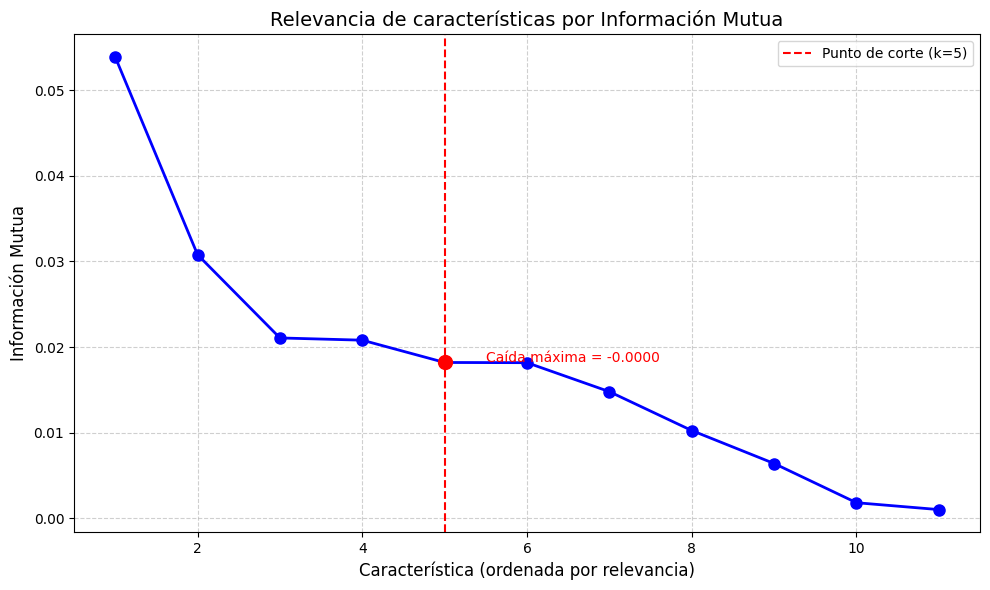


--- Criterio de selección ---
Se recomienda seleccionar las 5 mejores características
Características seleccionadas: ['Operability (O)', 'Availability (A)', 'Scalability (SC)', 'Security (SE)', 'Portability (PO)']


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelextrema

# Usando el ranking de Información Mutua que ya calculaste
mi_series = mi_resultados  # ya ordenado descendente
caracteristicas_ordenadas = mi_series.index.tolist()
valores = mi_series.values

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(valores)+1), valores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Característica (ordenada por relevancia)', fontsize=12)
plt.ylabel('Información Mutua', fontsize=12)
plt.title('Relevancia de características por Información Mutua', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Marcar el punto de corte por diferencia máxima entre valores consecutivos
diferencias = np.diff(valores)
max_diferencia_idx = np.argmax(diferencias)  # índice donde la caída es mayor
punto_corte = max_diferencia_idx + 1  # +1 porque diff reduce en 1

# Resaltar el punto de corte
plt.axvline(x=punto_corte, color='red', linestyle='--', 
            label=f'Punto de corte (k={punto_corte})')
plt.plot(punto_corte, valores[punto_corte-1], 'ro', markersize=10)

# También mostrar el valor de la caída
caida = diferencias[max_diferencia_idx]
plt.text(punto_corte + 0.5, valores[punto_corte-1] - caida/2, 
         f'Caída máxima = {caida:.4f}', fontsize=10, color='red')

plt.legend()
plt.tight_layout()
plt.show()

print(f"\n--- Criterio de selección ---")
print(f"Se recomienda seleccionar las {punto_corte} mejores características")
print(f"Características seleccionadas: {caracteristicas_ordenadas[:punto_corte]}")

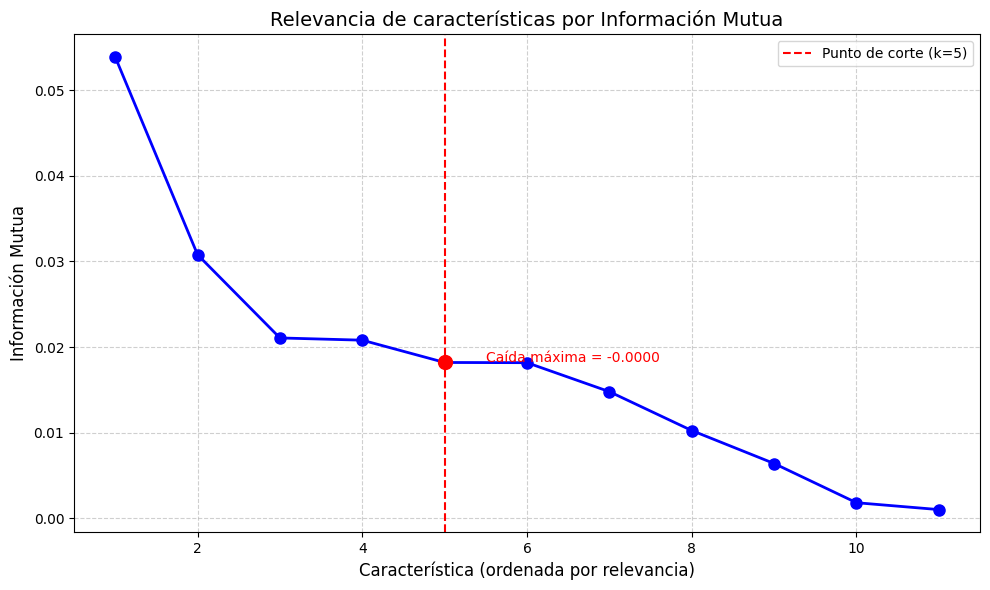


--- Criterio de selección ---
Se recomienda seleccionar las 5 mejores características
Características seleccionadas: ['Operability (O)', 'Availability (A)', 'Scalability (SC)', 'Security (SE)', 'Portability (PO)']


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelextrema

# Usando el ranking de Información Mutua que ya calculaste
mi_series = mi_resultados  # ya ordenado descendente
caracteristicas_ordenadas = mi_series.index.tolist()
valores = mi_series.values

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(valores)+1), valores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Característica (ordenada por relevancia)', fontsize=12)
plt.ylabel('Información Mutua', fontsize=12)
plt.title('Relevancia de características por Información Mutua', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Marcar el punto de corte por diferencia máxima entre valores consecutivos
diferencias = np.diff(valores)
max_diferencia_idx = np.argmax(diferencias)  # índice donde la caída es mayor
punto_corte = max_diferencia_idx + 1  # +1 porque diff reduce en 1

# Resaltar el punto de corte
plt.axvline(x=punto_corte, color='red', linestyle='--', 
            label=f'Punto de corte (k={punto_corte})')
plt.plot(punto_corte, valores[punto_corte-1], 'ro', markersize=10)

# También mostrar el valor de la caída
caida = diferencias[max_diferencia_idx]
plt.text(punto_corte + 0.5, valores[punto_corte-1] - caida/2, 
         f'Caída máxima = {caida:.4f}', fontsize=10, color='red')

plt.legend()
plt.tight_layout()
plt.show()

print(f"\n--- Criterio de selección ---")
print(f"Se recomienda seleccionar las {punto_corte} mejores características")
print(f"Características seleccionadas: {caracteristicas_ordenadas[:punto_corte]}")

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score

# 1. Definir características y objetivo
features = [
    'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 
    'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 
    'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 
    'Security (SE)', 'Usability (US)'
]

X = df[features]
y = df['IsFunctional']

# ==========================================
# PARTICIÓN DE DATOS (70% Entrenamiento, 30% Pruebas)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Definir la estrategia de Validación Cruzada (10-Fold estratificado)
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Tamaño Entrenamiento:", X_train.shape[0])
print("Tamaño Pruebas:", X_test.shape[0])
print("-" * 50)

# ==========================================
# 1) Árbol de Decisión (Todas las características)
# ==========================================
print("\n--- 1. Árbol de Decisión (Todas las características) ---")
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Validación Cruzada en Entrenamiento
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=cv_strategy, scoring='accuracy')
print(f"Exactitud Promedio (10-Fold CV): {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")

# Evaluación Final en Pruebas
dt_model.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt_model.predict(X_test))
print(f"Exactitud Final (30% Pruebas): {acc_dt:.4f}")

# ==========================================
# 2) Bayes Ingenuo (Todas las características)
# ==========================================
print("\n--- 2. Naive Bayes (Todas las características) ---")
nb_all_model = BernoulliNB()

cv_scores_nb = cross_val_score(nb_all_model, X_train, y_train, cv=cv_strategy, scoring='accuracy')
print(f"Exactitud Promedio (10-Fold CV): {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std():.4f})")

nb_all_model.fit(X_train, y_train)
acc_nb_all = accuracy_score(y_test, nb_all_model.predict(X_test))
print(f"Exactitud Final (30% Pruebas): {acc_nb_all:.4f}")

# ==========================================
# 3) Bayes Ingenuo (Selección por Árbol de Decisión)
# ==========================================
print("\n--- 3. Naive Bayes (Selección por Árbol de Decisión) ---")
importancias = dt_model.feature_importances_
dt_features = [features[i] for i in range(len(features)) if importancias[i] > 0]
print(f"Características seleccionadas ({len(dt_features)}): {dt_features}")

X_train_dt = X_train[dt_features]
X_test_dt = X_test[dt_features]

nb_dt_model = BernoulliNB()
cv_scores_nb_dt = cross_val_score(nb_dt_model, X_train_dt, y_train, cv=cv_strategy, scoring='accuracy')
print(f"Exactitud Promedio (10-Fold CV): {cv_scores_nb_dt.mean():.4f} (+/- {cv_scores_nb_dt.std():.4f})")

nb_dt_model.fit(X_train_dt, y_train)
acc_nb_dt = accuracy_score(y_test, nb_dt_model.predict(X_test_dt))
print(f"Exactitud Final (30% Pruebas): {acc_nb_dt:.4f}")

# ==========================================
# 4) Bayes Ingenuo (Selección por Información Mutua)
# ==========================================
print("\n--- 4. Naive Bayes (Selección por Información Mutua) ---")
mi_scores = mutual_info_classif(X_train, y_train, discrete_features=True, random_state=42)
mi_ranking = pd.Series(mi_scores, index=features).sort_values(ascending=False)

mi_features = mi_ranking[mi_ranking > 0].index.tolist()
if len(mi_features) < 3:
    mi_features = mi_ranking.head(5).index.tolist()

print(f"Características seleccionadas ({len(mi_features)}): {mi_features}")

X_train_mi = X_train[mi_features]
X_test_mi = X_test[mi_features]

nb_mi_model = BernoulliNB()
cv_scores_nb_mi = cross_val_score(nb_mi_model, X_train_mi, y_train, cv=cv_strategy, scoring='accuracy')
print(f"Exactitud Promedio (10-Fold CV): {cv_scores_nb_mi.mean():.4f} (+/- {cv_scores_nb_mi.std():.4f})")

nb_mi_model.fit(X_train_mi, y_train)
acc_nb_mi = accuracy_score(y_test, nb_mi_model.predict(X_test_mi))
print(f"Exactitud Final (30% Pruebas): {acc_nb_mi:.4f}")

Tamaño Entrenamiento: 435
Tamaño Pruebas: 187
--------------------------------------------------

--- 1. Árbol de Decisión (Todas las características) ---
Exactitud Promedio (10-Fold CV): 0.8548 (+/- 0.0495)
Exactitud Final (30% Pruebas): 0.8449

--- 2. Naive Bayes (Todas las características) ---
Exactitud Promedio (10-Fold CV): 0.7952 (+/- 0.0485)
Exactitud Final (30% Pruebas): 0.8396

--- 3. Naive Bayes (Selección por Árbol de Decisión) ---
Características seleccionadas (11): ['Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 'Security (SE)', 'Usability (US)']
Exactitud Promedio (10-Fold CV): 0.7952 (+/- 0.0485)
Exactitud Final (30% Pruebas): 0.8396

--- 4. Naive Bayes (Selección por Información Mutua) ---
Características seleccionadas (11): ['Operability (O)', 'Availability (A)', 'Scalability (SC)', 'Security (SE)', 'Look & Feel (LF)', 'Portability (PO)',

In [20]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# --- DEFINICIÓN DE ESTILOS Y COLORES (Para evitar NameError) ---
BOLD  = '\033[1m'
BLUE  = '\033[94m'
CYAN  = '\033[96m'
GREEN = '\033[92m'
RED   = '\033[91m'  # Aquí estaba el problema, ya quedó definido
END   = '\033[0m'

# Asegúrate de que estos nombres coincidan con tus variables en memoria
modelos_vivos = {
    "1) Árbol de Decisión": (dt_model, X_test),
    "2) Naive Bayes (Todo)": (nb_all_model, X_test),
    "3) Naive Bayes (Filtro Árbol)": (nb_dt_model, X_test[dt_features]),
    "4) Naive Bayes (Filtro Info Mutua)": (nb_mi_model, X_test[mi_features])
}

print(f"{BOLD}{BLUE}="*75)
print(f"   MÉTRICAS DE DESEMPEÑO Y ESTABILIDAD (SIN RE-ENTRENAR)   ")
print(f"="*75 + f"{END}\n")

for nombre, (modelo, x_data) in modelos_vivos.items():
    # 1. Predicción (Usando el modelo ya cargado)
    y_pred = modelo.predict(x_data)
    acc_final = accuracy_score(y_test, y_pred)
    
    # 2. Estabilidad mediante remuestreo (Bootstrapping sobre el test set)
    # Evaluamos la varianza del modelo sin volver a entrenarlo
    seeds = np.random.randint(0, 1000, 50)
    bootstrapped_scores = []
    for seed in seeds:
        indices = np.random.RandomState(seed).choice(len(y_test), len(y_test), replace=True)
        # Usamos .iloc para manejar los índices del remuestreo correctamente
        score = accuracy_score(y_test.iloc[indices], modelo.predict(x_data.iloc[indices]))
        bootstrapped_scores.append(score)
    
    std_dev = np.std(bootstrapped_scores)

    # 3. Impresión de resultados con los colores corregidos
    print(f"{BOLD}{CYAN}MODELO: {nombre}{END}")
    print(f"• Exactitud (Accuracy): {GREEN}{acc_final:.2%}{END}")
    
    # Evaluación de estabilidad basada en la desviación estándar
    status_color = GREEN if std_dev < 0.03 else RED
    status_text = "Estable" if std_dev < 0.03 else "Inestable"
    
    print(f"• Desviación Estándar (σ): {status_color}{std_dev:.4f} ({status_text}){END}")
    print(f"\n{BOLD}Reporte de Clasificación:{END}")
    print(classification_report(y_test, y_pred, target_names=['No Funcional (0)', 'Funcional (1)']))
    print("-" * 75 + "\n")

   MÉTRICAS DE DESEMPEÑO Y ESTABILIDAD (SIN RE-ENTRENAR)   

MODELO: 1) Árbol de Decisión
• Exactitud (Accuracy): 84.49%
• Desviación Estándar (σ): 0.0250 (Estable)

Reporte de Clasificación:
                  precision    recall  f1-score   support

No Funcional (0)       0.84      0.85      0.85        94
   Funcional (1)       0.85      0.84      0.84        93

        accuracy                           0.84       187
       macro avg       0.84      0.84      0.84       187
    weighted avg       0.84      0.84      0.84       187

---------------------------------------------------------------------------

MODELO: 2) Naive Bayes (Todo)
• Exactitud (Accuracy): 83.96%
• Desviación Estándar (σ): 0.0235 (Estable)

Reporte de Clasificación:
                  precision    recall  f1-score   support

No Funcional (0)       0.83      0.85      0.84        94
   Funcional (1)       0.85      0.83      0.84        93

        accuracy                           0.84       187
       macro a

In [21]:
import pandas as pd

# 1. Definimos 3 casos de prueba nuevos (Requisitos que no estaban en el dataset)
# 0 = Ausencia del atributo, 1 = Presencia del atributo
datos_prueba = {
    'Requisito A (Pura Funcionalidad)': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # Todo en 0
    'Requisito B (Enfocado en Usuario)': [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], # Look&Feel y Usabilidad
    'Requisito C (Crítico de Sistema)':  [1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0]  # Disponibilidad, FT, Perf, Scal, Sec
}

# Convertir a DataFrame con las columnas correctas
df_test_nuevo = pd.DataFrame.from_dict(datos_prueba, orient='index', columns=features)

print(f"{BOLD}{BLUE}="*70)
print(f"   PRUEBA DE PREDICCIÓN CON NUEVOS REQUISITOS   ")
print(f"="*70 + f"{END}\n")

# Diccionario de modelos cargados
modelos_activos = {
    "1) Árbol (Todo)": (dt_model, features),
    "2) NB (Todo)": (nb_all_model, features),
    "3) NB (Filtro Árbol)": (nb_dt_model, dt_features),
    "4) NB (Filtro Info Mutua)": (nb_mi_model, mi_features)
}

# Ejecutar predicciones
resultados_pred = []

for nombre_modelo, (modelo, feat_usadas) in modelos_activos.items():
    # Filtrar el DataFrame de prueba solo con las columnas que cada modelo conoce
    X_input = df_test_nuevo[feat_usadas]
    predicciones = modelo.predict(X_input)
    
    # Mapear 0/1 a texto para que se entienda
    labels = ["Funcional" if p == 1 else "No Funcional" for p in predicciones]
    resultados_pred.append([nombre_modelo] + labels)

# Mostrar tabla de resultados
columnas_tabla = ["Modelo", "Req. A (Vacío)", "Req. B (UI/UX)", "Req. C (Infra)"]
df_final_test = pd.DataFrame(resultados_pred, columns=columnas_tabla)

print(df_final_test.to_string(index=False))
print(f"\n{BOLD}Interpretación Esperada:{END}")
print("• El Req A (puros 0s) debería ser clasificado como 'Funcional'.")
print("• El Req C (muchos atributos de calidad) debería ser 'No Funcional'.")

   PRUEBA DE PREDICCIÓN CON NUEVOS REQUISITOS   

                   Modelo Req. A (Vacío) Req. B (UI/UX) Req. C (Infra)
          1) Árbol (Todo)      Funcional   No Funcional   No Funcional
             2) NB (Todo)      Funcional   No Funcional   No Funcional
     3) NB (Filtro Árbol)      Funcional   No Funcional   No Funcional
4) NB (Filtro Info Mutua)      Funcional   No Funcional   No Funcional

Interpretación Esperada:
• El Req A (puros 0s) debería ser clasificado como 'Funcional'.
• El Req C (muchos atributos de calidad) debería ser 'No Funcional'.
